In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from pathlib import Path
from IPython.display import display

from sklearn import metrics

# versions
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"seaborn: {sns.__version__}")
print(f"tensorflow: {tf.__version__}")

I0000 00:00:1780671274.262418    5941 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780671274.288944    5941 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


numpy: 2.4.6
pandas: 3.0.3
seaborn: 0.13.2
tensorflow: 2.21.0


In [2]:
data_path = Path("../Finalized_Feature_Sets/model_data_simple.parquet")

model_data_simple = pd.read_parquet(
    data_path,
    engine="pyarrow"
)

model_data_simple.shape

(1700, 31)

In [3]:
feature_cols = model_data_simple.columns.drop(["ZSN", "train_dummy"])

x_train = model_data_simple.loc[model_data_simple["train_dummy"] == 1, feature_cols]
y_train = model_data_simple.loc[model_data_simple["train_dummy"] == 1, "ZSN"]

x_test = model_data_simple.loc[model_data_simple["train_dummy"] == 0, feature_cols]
y_test = model_data_simple.loc[model_data_simple["train_dummy"] == 0, "ZSN"]

# Naive Baseline Model: Majority Class

* only uses the training data to determine the majority class and predicts that for all instances in the test set
* serves as a baseline to compare the performance of more complex models; logistic regression usually is the benchmark after the majority class model
* is a deterministic model (does not involve any randomness in its predictions) and as such does not require a random seed for reproducibility

In [4]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# -----------------------------
# 1. Define train/test features and outcome
# -----------------------------

feature_cols = model_data_simple.columns.drop(["ZSN", "train_dummy"])

x_train = model_data_simple.loc[model_data_simple["train_dummy"] == 1, feature_cols]
y_train = model_data_simple.loc[model_data_simple["train_dummy"] == 1, "ZSN"]

x_test = model_data_simple.loc[model_data_simple["train_dummy"] == 0, feature_cols]
y_test = model_data_simple.loc[model_data_simple["train_dummy"] == 0, "ZSN"]


# -----------------------------
# 2. Majority class naive model
# -----------------------------

majority_model = DummyClassifier(strategy="most_frequent")

majority_model.fit(x_train, y_train)

y_pred = majority_model.predict(x_test)
y_prob = majority_model.predict_proba(x_test)[:, 1]


# -----------------------------
# 3. Evaluate performance
# -----------------------------

print("Majority class predicted:", majority_model.classes_[majority_model.class_prior_.argmax()])

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("PR AUC:", average_precision_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Majority class predicted: 0
Accuracy: 0.7464788732394366
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC AUC: 0.5
PR AUC: 0.2535211267605634

Confusion Matrix:
[[318   0]
 [108   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.85       318
           1       0.00      0.00      0.00       108

    accuracy                           0.75       426
   macro avg       0.37      0.50      0.43       426
weighted avg       0.56      0.75      0.64       426



"Majority Class predicted: 0" means no myocardial infarction (MI) predicted for all patients in the test set, which is the majority class in the training data. This model will have high accuracy if the majority class is dominant

# Calculating Metrics for Logistic Regression: 
* logistic regression was already trained and evaluated but it is calculated here to standardize metrics for comparison

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# -----------------------------
# 1. Define train/test features and outcome
# -----------------------------

feature_cols = model_data_simple.columns.drop(["ZSN", "train_dummy"])

x_train = model_data_simple.loc[model_data_simple["train_dummy"] == 1, feature_cols]
y_train = model_data_simple.loc[model_data_simple["train_dummy"] == 1, "ZSN"]

x_test = model_data_simple.loc[model_data_simple["train_dummy"] == 0, feature_cols]
y_test = model_data_simple.loc[model_data_simple["train_dummy"] == 0, "ZSN"]


# -----------------------------
# 2. One-hot encode categorical predictors
# -----------------------------

x_train = pd.get_dummies(x_train, drop_first=True)
x_test = pd.get_dummies(x_test, drop_first=True)

x_train, x_test = x_train.align(
    x_test,
    join="left",
    axis=1,
    fill_value=0
)


# -----------------------------
# 3. Standardize predictors
# -----------------------------

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


# -----------------------------
# 4. Logistic regression model
# -----------------------------

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=321
)

logistic_model.fit(x_train_scaled, y_train)

y_pred = logistic_model.predict(x_test_scaled)
y_prob = logistic_model.predict_proba(x_test_scaled)[:, 1]


# -----------------------------
# 5. Evaluate performance
# -----------------------------

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("PR AUC:", average_precision_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8028169014084507
Precision: 0.875
Recall: 0.25925925925925924
F1: 0.4
ROC AUC: 0.7225425110645237
PR AUC: 0.5655289150719363

Confusion Matrix:
[[314   4]
 [ 80  28]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.99      0.88       318
           1       0.88      0.26      0.40       108

    accuracy                           0.80       426
   macro avg       0.84      0.62      0.64       426
weighted avg       0.82      0.80      0.76       426



# Simple MLP Model

* requires purely numeric features
* some form of normalization or standardization is typically needed for MLPs to perform well, especially if the features are on different scales
    * e.g. standardization (z-score normalization), min-max normalization or unit-norm normalization

In [9]:
# One-hot encode categorical predictors
x_train = pd.get_dummies(x_train, drop_first=False)
x_test = pd.get_dummies(x_test, drop_first=False)

# Ensure train/test have identical columns
x_train, x_test = x_train.align(
    x_test,
    join="left",
    axis=1,
    fill_value=0
)

In [10]:
# standardscalar is a common choice for MLPs, especially when features are on different scales
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [16]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=321
)

mlp_model.fit(x_train_scaled, y_train)

/home/Max_Vo/anaconda3/envs/Gen_DS/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(16,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",321


In [17]:
print("Input features:", mlp_model.n_features_in_)
print("Hidden layers:", mlp_model.hidden_layer_sizes)
print("Output classes:", mlp_model.n_outputs_)

Input features: 46
Hidden layers: (16,)
Output classes: 1


In [19]:
y_pred = mlp_model.predict(x_test_scaled)
y_prob = mlp_model.predict_proba(x_test_scaled)[:, 1]

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("PR AUC:", average_precision_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7183098591549296
Precision: 0.43617021276595747
Recall: 0.37962962962962965
F1: 0.40594059405940597
ROC AUC: 0.6044432797577451
PR AUC: 0.4264220140073839

Confusion Matrix:
[[265  53]
 [ 67  41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.82       318
           1       0.44      0.38      0.41       108

    accuracy                           0.72       426
   macro avg       0.62      0.61      0.61       426
weighted avg       0.71      0.72      0.71       426



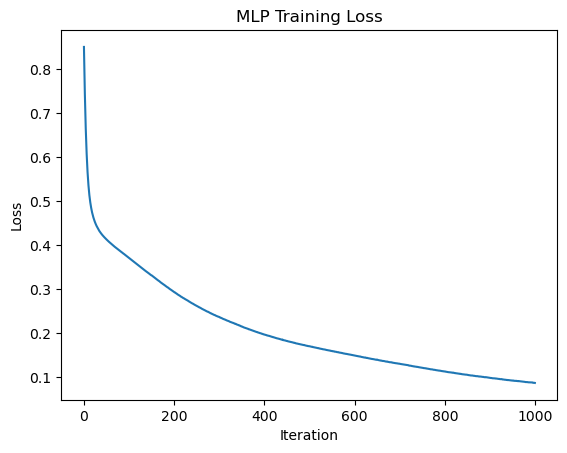

In [21]:
import matplotlib.pyplot as plt

plt.plot(mlp_model.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("MLP Training Loss")
plt.show()

# Baseline residual MLP / ResNet-style model for tabular data using TensorFlow/Keras

* isolated imports for clarity

In [6]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

random_seed = 321

np.random.seed(random_seed)
tf.random.set_seed(random_seed)

In [7]:
# -----------------------------
# 1. Define train/test features and outcome
# -----------------------------

feature_cols = model_data_simple.columns.drop(["ZSN", "train_dummy"])

x_train = model_data_simple.loc[model_data_simple["train_dummy"] == 1, feature_cols]
y_train = model_data_simple.loc[model_data_simple["train_dummy"] == 1, "ZSN"]

x_test = model_data_simple.loc[model_data_simple["train_dummy"] == 0, feature_cols]
y_test = model_data_simple.loc[model_data_simple["train_dummy"] == 0, "ZSN"]

In [8]:
# -----------------------------
# 2. One-hot encode categorical predictors
# -----------------------------

x_train = pd.get_dummies(x_train, drop_first=False)
x_test = pd.get_dummies(x_test, drop_first=False)

x_train, x_test = x_train.align(
    x_test,
    join="left",
    axis=1,
    fill_value=0
)

print(set(x_train.columns) - set(x_test.columns))  # should be empty set
print(x_train.shape)
print(x_test.shape)

set()
(1274, 46)
(426, 46)


In [9]:
# -----------------------------
# 3. Standardize predictors
# -----------------------------

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

y_train_array = y_train.to_numpy()
y_test_array = y_test.to_numpy()

In [10]:
# -----------------------------
# 4. Define a basic residual block
# -----------------------------

def residual_block(x, units, dropout_rate=0.10):
    shortcut = x

    x = tf.keras.layers.Dense(units, activation="relu")(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    x = tf.keras.layers.Dense(units, activation=None)(x)

    x = tf.keras.layers.Add()([shortcut, x])
    x = tf.keras.layers.Activation("relu")(x)

    return x

In [11]:
# -----------------------------
# 5. Build basic ResNet-style tabular model
# -----------------------------

input_dim = x_train_scaled.shape[1]

inputs = tf.keras.Input(shape=(input_dim,))

# Project input to 32 dimensions so residual blocks have matching dimensions
x = tf.keras.layers.Dense(32, activation="relu")(inputs)

# Basic residual blocks
x = residual_block(x, units=32, dropout_rate=0.10)
x = residual_block(x, units=32, dropout_rate=0.10)

# Final classification layer
x = tf.keras.layers.Dense(16, activation="relu")(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

resnet_model = tf.keras.Model(inputs=inputs, outputs=outputs)

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="roc_auc"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR")
    ]
)

resnet_model.summary()

I0000 00:00:1780671503.185235    5941 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9425 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 46)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      1,504 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      1,056 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      1,056 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32)        │          0 │ dense[0][0],      │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32)        │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      1,056 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      1,056 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32)        │          0 │ activation[0][0], │
│                     │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32)        │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 16)        │        528 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         17 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,273 (24.50 KB)

 Trainable params: 6,273 (24.50 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# -----------------------------
# 6. Fit model
# -----------------------------

history = resnet_model.fit(
    x_train_scaled,
    y_train_array,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100


I0000 00:00:1780671508.612286    6355 service.cc:153] XLA service 0x7f0c78049e80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780671508.612303    6355 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.17.0)
I0000 00:00:1780671508.649406    6355 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780671508.825417    6355 cuda_dnn.cc:461] Loaded cuDNN version 91700
I0000 00:00:1780671508.870799    6355 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3356__.29


 1/32 ━━━━━━━━━━━━━━━━━━━━ 1:30 3s/step - accuracy: 0.2812 - loss: 1.0513 - pr_auc: 0.2462 - roc_auc: 0.5573

I0000 00:00:1780671510.592842    6355 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1780671510.827055    6355 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3356__.29


32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - accuracy: 0.6330 - loss: 0.6693 - pr_auc: 0.2597 - roc_auc: 0.4988 - val_accuracy: 0.8510 - val_loss: 0.4627 - val_pr_auc: 0.1085 - val_roc_auc: 0.4414
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7723 - loss: 0.5287 - pr_auc: 0.4294 - roc_auc: 0.6588 - val_accuracy: 0.8275 - val_loss: 0.4971 - val_pr_auc: 0.1358 - val_roc_auc: 0.5287
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7880 - loss: 0.4939 - pr_auc: 0.5391 - roc_auc: 0.7197 - val_accuracy: 0.8196 - val_loss: 0.4929 - val_pr_auc: 0.1593 - val_roc_auc: 0.5592
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7988 - loss: 0.4668 - pr_auc: 0.5759 - roc_auc: 0.7632 - val_accuracy: 0.7686 - val_loss: 0.5196 - val_pr_auc: 0.1738 - val_roc_auc: 0.5668
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8096 - loss: 0.4453 - pr_auc: 0.6190 - roc_auc: 0.7876 - val_accuracy: 0.7529 - val_loss: 0.5261 - val_pr_auc: 0.2312 - val_r

In [13]:
# -----------------------------
# 7. Predict on test set
# -----------------------------

y_prob = resnet_model.predict(x_test_scaled).ravel()
y_pred = (y_prob >= 0.50).astype(int)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


In [14]:
# -----------------------------
# 8. Evaluate performance
# -----------------------------

print("Accuracy:", accuracy_score(y_test_array, y_pred))
print("Precision:", precision_score(y_test_array, y_pred, zero_division=0))
print("Recall:", recall_score(y_test_array, y_pred, zero_division=0))
print("F1:", f1_score(y_test_array, y_pred, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test_array, y_prob))
print("PR AUC:", average_precision_score(y_test_array, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_array, y_pred))

print("\nClassification Report:")
print(classification_report(y_test_array, y_pred, zero_division=0))

Accuracy: 0.7816901408450704
Precision: 0.5974025974025974
Recall: 0.42592592592592593
F1: 0.4972972972972973
ROC AUC: 0.6770906126252039
PR AUC: 0.4980339678392973

Confusion Matrix:
[[287  31]
 [ 62  46]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       318
           1       0.60      0.43      0.50       108

    accuracy                           0.78       426
   macro avg       0.71      0.66      0.68       426
weighted avg       0.77      0.78      0.77       426



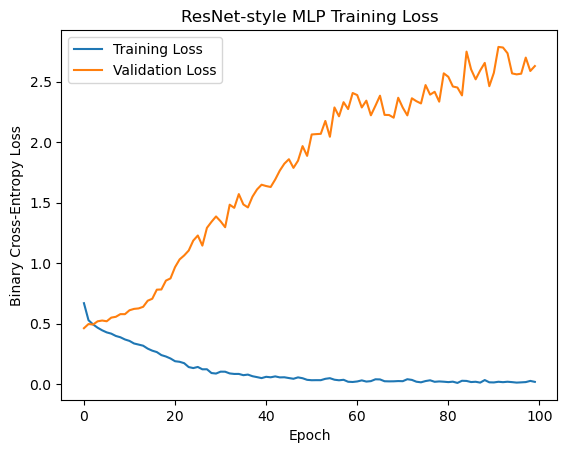

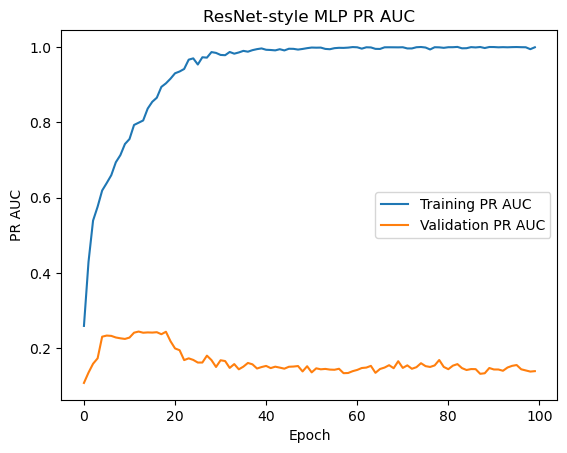

In [15]:
# -----------------------------
# 9. Plot training curves
# -----------------------------

import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("ResNet-style MLP Training Loss")
plt.legend()
plt.show()

plt.plot(history.history["pr_auc"], label="Training PR AUC")
plt.plot(history.history["val_pr_auc"], label="Validation PR AUC")
plt.xlabel("Epoch")
plt.ylabel("PR AUC")
plt.title("ResNet-style MLP PR AUC")
plt.legend()
plt.show()